# 2D Cut and Projection of 4D Simple Cubic Lattice

This notebook calculates and visualizes a 2D cut of a 4D simple cubic lattice potential, showing three-fold and six-fold rotationally symmetric potentials. 

## Physics and Geometry
The 4D superspace potential is a simple cubic lattice defined as:
$$ V(X_1, X_2, X_3, X_4) = \sum_{i=1}^{4} \sin(X_i) $$
where $X_i = \vec{v}_{1,i} x + \vec{v}_{2,i} y + \phi_i$ are the coordinates on a 2D cut plane translated by a 2D offset $\vec{\phi}_{\text{plane}} = (\phi_{n1}, \phi_{n2})$ in the orthogonal subspace.

To achieve 6-fold (or 3-fold) rotational symmetry, the cutting plane must be oriented such that it is perpendicular to one of the 4D coordinate axes (e.g., $X_4$), and makes equal angles with the other three axes ($X_1, X_2, X_3$). This results in three active wavevectors in the plane that are equal in length and spaced by $120^\circ$.

The 4D offset is parameterized as:
$$ \vec{\phi} = \phi_{n1} \vec{n}_1 + \phi_{n2} \vec{n}_2 $$
where $\vec{n}_1, \vec{n}_2$ are orthonormal vectors spanning the orthogonal subspace of the plane.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def get_cut_vectors(orthogonal_axis = 4):
    """
    Returns the orthonormal basis vectors for the 2D cut plane (v1, v2)
    and the orthogonal normal space (n1, n2) in 4D.
    
    Args:
        orthogonal_axis (int): The 4D axis (1, 2, 3, or 4) to make orthogonal to the plane.
        
    Returns:
        v1, v2, n1, n2: Four 4D numpy arrays.
    """
    v1 = np.zeros(4)
    v2 = np.zeros(4)
    n1 = np.zeros(4)
    n2 = np.zeros(4)
    
    # Identify the indices of the other three axes
    other_axes = [i for i in range(1, 5) if i != orthogonal_axis]
    
    # Populate the normal vectors
    # n1: diagonal in the other three axes
    for idx in other_axes:
        n1[idx - 1] = 1.0 / np.sqrt(3.0)
    # n2: along the orthogonal axis
    n2[orthogonal_axis - 1] = 1.0
    
    # Populate the cut plane vectors (v1, v2)
    # v1: (2, -1, -1) normalized in the other three axes
    v1[other_axes[0] - 1] = 2.0 / np.sqrt(6.0)
    v1[other_axes[1] - 1] = -1.0 / np.sqrt(6.0)
    v1[other_axes[2] - 1] = -1.0 / np.sqrt(6.0)
    
    # v2: (0, 1, -1) normalized in the other three axes
    v2[other_axes[0] - 1] = 0.0
    v2[other_axes[1] - 1] = 1.0 / np.sqrt(2.0)
    v2[other_axes[2] - 1] = -1.0 / np.sqrt(2.0)
    
    return v1, v2, n1, n2

In [3]:
def calculate_4d_cut_potential(orthogonal_axis = 4, plane_offset = (0.0, 0.0), x_lims = (-10.0, 10.0), y_lims = (-10.0, 10.0), res = 500):
    """
    Evaluates the 2D cut of the 4D simple cubic potential on a grid.
    
    Args:
        orthogonal_axis (int): Coordinate axis (1, 2, 3, or 4) to make orthogonal to the plane.
        plane_offset (tuple): Two-dimensional offset (phi_n1, phi_n2) in the orthogonal subspace.
        x_lims (tuple): Range for x coordinates.
        y_lims (tuple): Range for y coordinates.
        res (int): Grid resolution.
        
    Returns:
        X, Y, V: Grid coordinates and calculated potential.
    """
    # 1. Get the basis vectors
    v1, v2, n1, n2 = get_cut_vectors(orthogonal_axis)
    
    # 2. Create vectorized 2D spatial grid
    x = np.linspace(x_lims[0], x_lims[1], res)
    y = np.linspace(y_lims[0], y_lims[1], res)
    X, Y = np.meshgrid(x, y)
    
    # 3. Compute the 4D phase offset vector
    phi_n1, phi_n2 = plane_offset
    phi = phi_n1 * n1 + phi_n2 * n2
    
    # Initialize potential array
    V = np.zeros_like(X)
    
    # 4. Vectorized calculation of the potential landscape
    # Formula: V(x,y) = sum_{i=1}^4 sin(X_i)
    # where X_i = v1_i * x + v2_i * y + phi_i
    for i in range(4):
        Xi = v1[i] * X + v2[i] * Y + phi[i]
        V = V + np.sin(Xi)
        
    return X, Y, V

In [4]:
def visualize_potential(X, Y, V, orthogonal_axis, plane_offset):
    """
    Visualizes the potential using strict object-oriented Matplotlib.
    """
    fig, ax = plt.subplots(figsize = (10, 8))
    
    # Plot potential landscape
    im = ax.pcolormesh(X, Y, V, cmap = 'viridis', shading = 'auto')
    
    # Apply formatting and labels
    ax.set_aspect('equal')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_title(f'2D Cut Potential of 4D Simple Cubic Lattice\n' + 
                 f'Orthogonal Axis = {orthogonal_axis}, Plane Offset = {plane_offset}')
    
    # Add a colorbar
    cbar = fig.colorbar(im, ax = ax)
    cbar.set_label('Potential Energy (a.u.)')
    
    plt.tight_layout()
    plt.show()

## 1. Six-Fold Rotationally Symmetric Potential
Setting $\phi_{n1} = \frac{\pi \sqrt{3}}{2}$ and $\phi_{n2} = 0.0$ yields a cosine-type potential with exact six-fold rotational symmetry.

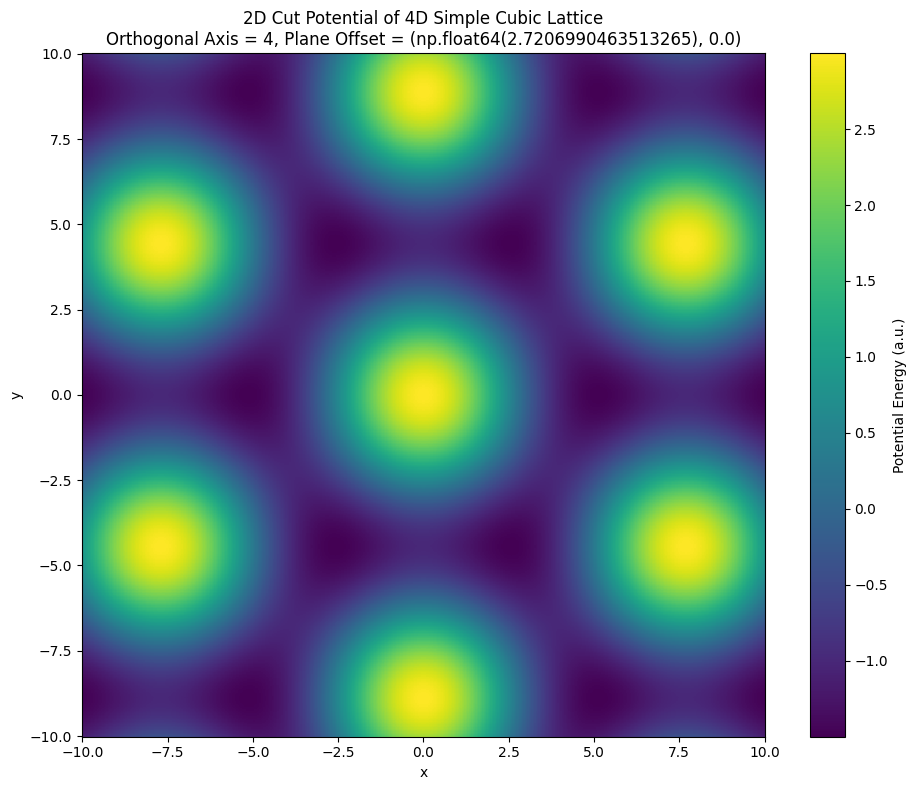

In [5]:
Orthogonal_axis = 4
phi_n1_6fold = np.pi * np.sqrt(3.0) / 2.0
phi_n2_6fold = 0.0
Plane_offset_6fold = (phi_n1_6fold, phi_n2_6fold)

X_grid, Y_grid, Potential_6fold = calculate_4d_cut_potential(
    orthogonal_axis = Orthogonal_axis,
    plane_offset = Plane_offset_6fold,
    x_lims = (-10.0, 10.0),
    y_lims = (-10.0, 10.0),
    res = 500
)

visualize_potential(X_grid, Y_grid, Potential_6fold, Orthogonal_axis, Plane_offset_6fold)

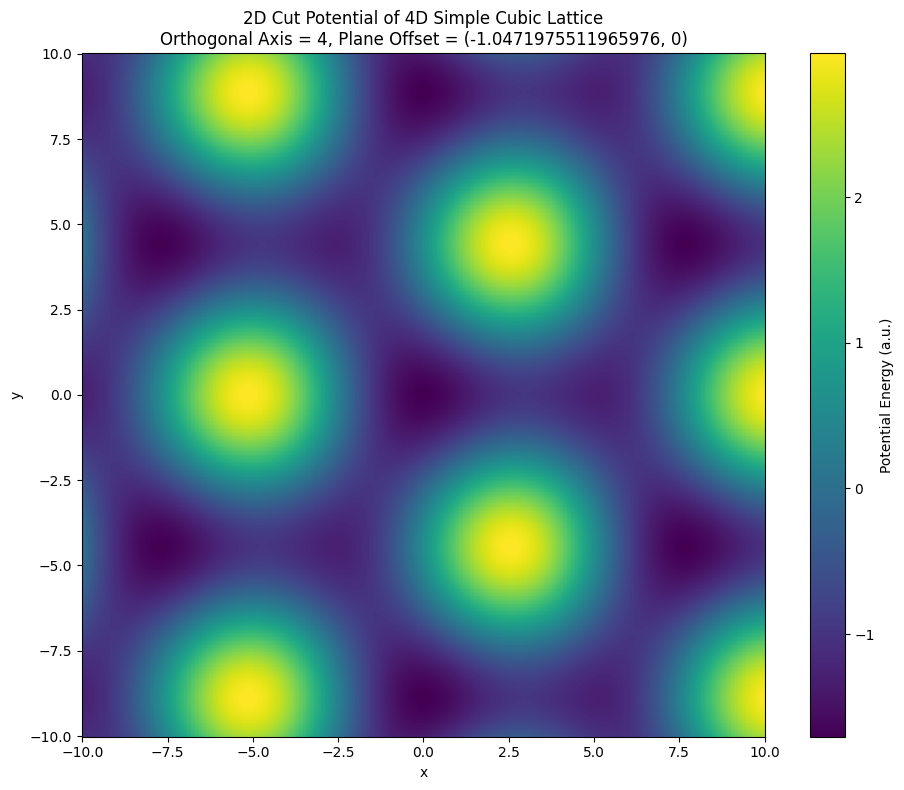

In [13]:
Orthogonal_axis = 4
Plane_offset_arb = (-np.pi/3, 0)

X_grid, Y_grid, Potential_6fold = calculate_4d_cut_potential(
    orthogonal_axis = Orthogonal_axis,
    plane_offset = Plane_offset_arb,
    x_lims = (-10.0, 10.0),
    y_lims = (-10.0, 10.0),
    res = 500
)

visualize_potential(X_grid, Y_grid, Potential_6fold, Orthogonal_axis, Plane_offset_arb)

## 2. Three-Fold Rotationally Symmetric Potential
Setting $\phi_{n1} = 0.0$ and $\phi_{n2} = 0.0$ yields a sine-type potential with three-fold rotational symmetry (and six-fold anti-symmetry).

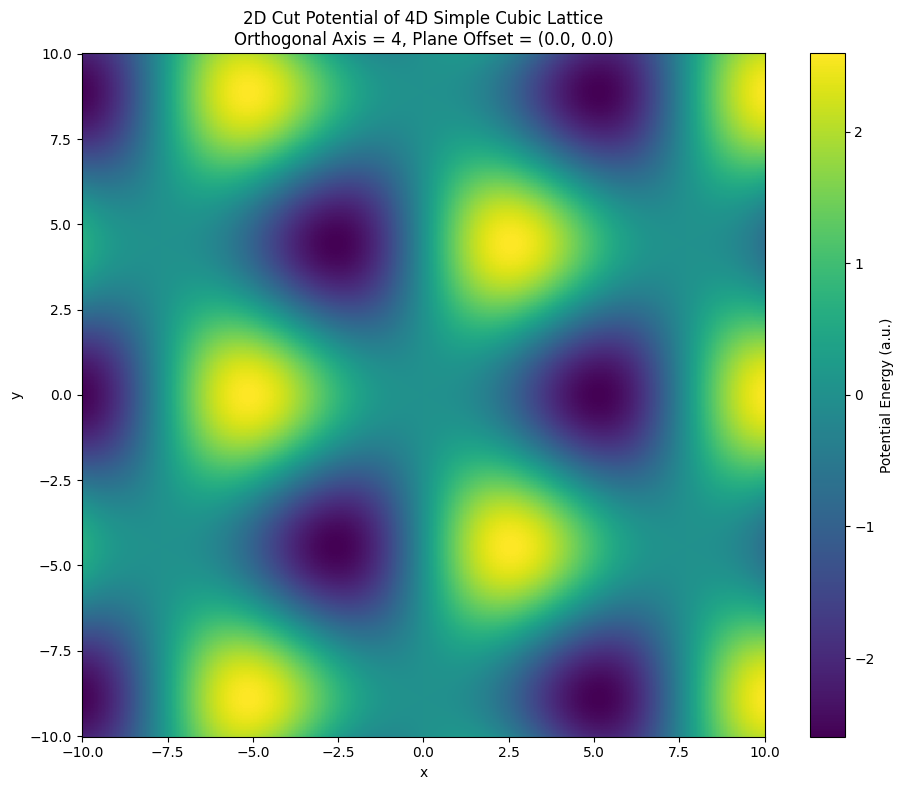

In [6]:
Plane_offset_3fold = (0.0, 0.0)

X_grid, Y_grid, Potential_3fold = calculate_4d_cut_potential(
    orthogonal_axis = Orthogonal_axis,
    plane_offset = Plane_offset_3fold,
    x_lims = (-10.0, 10.0),
    y_lims = (-10.0, 10.0),
    res = 500
)

visualize_potential(X_grid, Y_grid, Potential_3fold, Orthogonal_axis, Plane_offset_3fold)